# Project Title
Data-Driven HR Analytics: Optimizing Employee Retention and Training Efficiency

## Introduction 

Employees are the most important part of any successful company. To make a business grow, it is vital to keep workers happy, give them the right training, and hire the best people.  This project looks into our HR data—including employee records, satisfaction surveys, and training details—to find the main reasons why people are leaving the company and why some training programs are failing. The goal of this analysis is to find clear ways to make our workplace better, save company money, and keep our top talent. 

## Problem Statement

The company faces a major challenge in keeping its employees, as seen in the high number of people leaving the organization. This issue goes hand in hand with low employee satisfaction and poor engagement scores across the workplace. Additionally, a lot of the training budget is being lost because many development programs are either not finished or failed by employees, which hurts the company’s budget and daily operations.

## Objectives:
__Questions that will guide the analysis to solve the problem__

1. Find out which departments and job roles have the highest number of employees leaving.  
2. Understand how low job satisfaction affects an employee's decision to quit.  
3. Discover why training programs are failing to better direct future training investments.  
4. Improve future hiring plans by studying applicant data and outcomes.  

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns

In [2]:
employee = pd.read_csv("employee_data.csv")
engagement = pd.read_csv("employee_engagement_survey_data.csv")
training = pd.read_csv("training_and_development_data.csv")
recruitment = pd.read_csv("recruitment_data.csv")

In [3]:
# Here I will merge two data together
merged_step1 = pd.merge(employee, engagement, left_on = 'EmpID', right_on = 'Employee ID', how='left')
merged_step1

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,LocationCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating,Employee ID,Survey Date,Engagement Score,Satisfaction Score,Work-Life Balance Score
0,3427,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,34904,White,Widowed,Fully Meets,4,3427,14-01-2023,1,2,3
1,3428,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,6593,Hispanic,Widowed,Fully Meets,3,3428,09-09-2022,2,1,5
2,3429,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2330,Hispanic,Widowed,Fully Meets,4,3429,27-05-2023,1,2,1
3,3430,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,58782,Other,Single,Fully Meets,2,3430,16-06-2023,5,5,4
4,3431,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,33174,Other,Married,Fully Meets,3,3431,25-11-2022,2,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,3422,Jakobe,Erickson,22-Jun-22,07-Aug-22,Production Technician I,Bethany Carter,jakobe.erickson@bilearner.com,PYZ,Leave of Absence,...,44500,Other,Widowed,Fully Meets,3,3422,08-06-2023,1,1,3
2996,3423,Adyson,Strickland,28-Dec-20,NaN,Production Technician I,Caroline Harris,adyson.strickland@bilearner.com,SVG,Active,...,35444,Black,Widowed,Fully Meets,3,3423,19-09-2022,4,5,3
2997,3424,Annabel,Wilkins,09-Dec-20,04-Aug-22,Production Technician I,Mr. James Castillo,annabel.wilkins@bilearner.com,TNS,Voluntarily Terminated,...,6608,White,Single,Fully Meets,2,3424,14-03-2023,2,4,5
2998,3425,Kendra,Braun,28-May-19,23-Oct-21,Production Technician I,Michael Woods,kendra.braun@bilearner.com,WBL,Voluntarily Terminated,...,3807,Hispanic,Divorced,Fully Meets,2,3425,25-12-2022,5,2,3


In [4]:
# Here I will merge the old variable of marge with the anther data together to marge all dataset
dataset = pd.merge(merged_step1, training, on = 'Employee ID', how = 'left')
dataset

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,3427,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2,3,15-Jul-23,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11
1,3428,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,1,5,12-Sep-22,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02
2,3429,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2,1,13-Aug-22,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28
3,3430,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,5,4,15-Dec-22,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78
4,3431,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,5,3,13-Jul-23,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,3422,Jakobe,Erickson,22-Jun-22,07-Aug-22,Production Technician I,Bethany Carter,jakobe.erickson@bilearner.com,PYZ,Leave of Absence,...,1,3,13-Mar-23,Communication Skills,Internal,Failed,Alyssaview,Paul Davis,1,707.96
2996,3423,Adyson,Strickland,28-Dec-20,NaN,Production Technician I,Caroline Harris,adyson.strickland@bilearner.com,SVG,Active,...,5,3,14-Oct-22,Technical Skills,External,Completed,Kramerbury,David Matthews,1,439.65
2997,3424,Annabel,Wilkins,09-Dec-20,04-Aug-22,Production Technician I,Mr. James Castillo,annabel.wilkins@bilearner.com,TNS,Voluntarily Terminated,...,4,5,18-Aug-22,Project Management,Internal,Completed,Lozanoburgh,Julie Bell,5,981.13
2998,3425,Kendra,Braun,28-May-19,23-Oct-21,Production Technician I,Michael Woods,kendra.braun@bilearner.com,WBL,Voluntarily Terminated,...,2,3,19-May-23,Technical Skills,External,Completed,Hughesburgh,Paige Figueroa,3,184.27


In [5]:
# Here I want to see the data size, how many columns and how many rows
dataset.shape

(3000, 39)

In [6]:
# Here I want to see the data, but only from the first 5 rows
dataset.head()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,3427,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2,3,15-Jul-23,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11
1,3428,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,1,5,12-Sep-22,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02
2,3429,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2,1,13-Aug-22,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28
3,3430,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,5,4,15-Dec-22,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78
4,3431,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,5,3,13-Jul-23,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03


In [7]:
# Here I want to see the data, but only from the last 5 rows
dataset.tail()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
2995,3422,Jakobe,Erickson,22-Jun-22,07-Aug-22,Production Technician I,Bethany Carter,jakobe.erickson@bilearner.com,PYZ,Leave of Absence,...,1,3,13-Mar-23,Communication Skills,Internal,Failed,Alyssaview,Paul Davis,1,707.96
2996,3423,Adyson,Strickland,28-Dec-20,NaN,Production Technician I,Caroline Harris,adyson.strickland@bilearner.com,SVG,Active,...,5,3,14-Oct-22,Technical Skills,External,Completed,Kramerbury,David Matthews,1,439.65
2997,3424,Annabel,Wilkins,09-Dec-20,04-Aug-22,Production Technician I,Mr. James Castillo,annabel.wilkins@bilearner.com,TNS,Voluntarily Terminated,...,4,5,18-Aug-22,Project Management,Internal,Completed,Lozanoburgh,Julie Bell,5,981.13
2998,3425,Kendra,Braun,28-May-19,23-Oct-21,Production Technician I,Michael Woods,kendra.braun@bilearner.com,WBL,Voluntarily Terminated,...,2,3,19-May-23,Technical Skills,External,Completed,Hughesburgh,Paige Figueroa,3,184.27
2999,3426,Chace,Kerr,27-Apr-22,NaN,Production Technician I,Javier Mccall,chace.kerr@bilearner.com,BPC,Active,...,3,2,02-May-23,Leadership Development,Internal,Failed,North Joshuatown,Joel Brooks,5,675.37


In [8]:
# Here I want to see the names of all the Colms
dataset.columns

Index(['EmpID', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title',
       'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus',
       'EmployeeType', 'PayZone', 'EmployeeClassificationType',
       'TerminationType', 'TerminationDescription', 'DepartmentType',
       'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode',
       'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score',
       'Current Employee Rating', 'Employee ID', 'Survey Date',
       'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score',
       'Training Date', 'Training Program Name', 'Training Type',
       'Training Outcome', 'Location', 'Trainer', 'Training Duration(Days)',
       'Training Cost'],
      dtype='object')

In [10]:
# Here I want to check if I have any missing data
dataset.isnull

<bound method DataFrame.isnull of       EmpID FirstName    LastName  StartDate   ExitDate  \
0      3427     Uriah     Bridges  20-Sep-19        NaN   
1      3428     Paula       Small  11-Feb-23        NaN   
2      3429    Edward        Buck  10-Dec-18        NaN   
3      3430   Michael     Riordan  21-Jun-21        NaN   
4      3431   Jasmine       Onque  29-Jun-19        NaN   
...     ...       ...         ...        ...        ...   
2995   3422    Jakobe    Erickson  22-Jun-22  07-Aug-22   
2996   3423    Adyson  Strickland  28-Dec-20        NaN   
2997   3424   Annabel     Wilkins  09-Dec-20  04-Aug-22   
2998   3425    Kendra       Braun  28-May-19  23-Oct-21   
2999   3426     Chace        Kerr  27-Apr-22        NaN   

                        Title          Supervisor  \
0     Production Technician I        Peter Oneill   
1     Production Technician I     Renee Mccormick   
2          Area Sales Manager      Crystal Walker   
3          Area Sales Manager      Rebekah Wr

In [14]:
# Here I want to see a summary of the data, in terms of the mean, median, etc
dataset.describe()

,EmpID,LocationCode,Current Employee Rating,Employee ID,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Duration(Days),Training Cost
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2500.500000,44997.180667,2.969000,2500.500000,2.939667,3.022000,2.989000,2.975667,558.628697
std,866.169729,29987.331783,1.015078,866.169729,1.433426,1.408845,1.409329,1.417890,263.217698
min,1001.000000,1013.000000,1.000000,1001.000000,1.000000,1.000000,1.000000,1.000000,100.040000
25%,1750.750000,17546.000000,2.000000,1750.750000,2.000000,2.000000,2.000000,2.000000,327.587500
50%,2500.500000,44150.500000,3.000000,2500.500000,3.000000,3.000000,3.000000,3.000000,572.125000
75%,3250.250000,71481.250000,3.000000,3250.250000,4.000000,4.000000,4.000000,4.000000,786.987500
max,4000.000000,98052.000000,5.000000,4000.000000,5.000000,5.000000,5.000000,5.000000,999.970000


### Data Handling: 
__Cleaning, transforming, and combining data__

In [13]:
# Here I want to see if there are any duplicates in the data
dataset.duplicated().sum()

0

In [12]:
dataset[['TerminationDescription']]

,TerminationDescription
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2995,In forget fast.
2996,NaN
2997,Smile high bar white spend forget choice near.
2998,Fine expect election either turn.


In [11]:
# Here I want to check if I have any missing data
dataset.isnull().sum()

EmpID                            0
FirstName                        0
LastName                         0
StartDate                        0
ExitDate                      1467
Title                            0
Supervisor                       0
ADEmail                          0
BusinessUnit                     0
EmployeeStatus                   0
EmployeeType                     0
PayZone                          0
EmployeeClassificationType       0
TerminationType                  0
TerminationDescription        1467
DepartmentType                   0
Division                         0
DOB                              0
State                            0
JobFunctionDescription           0
GenderCode                       0
LocationCode                     0
RaceDesc                         0
MaritalDesc                      0
Performance Score                0
Current Employee Rating          0
Employee ID                      0
Survey Date                      0
Engagement Score    

In [9]:
# Here I want to see the type of Colms found in the data
dataset.dtypes

EmpID                           int64
FirstName                      object
LastName                       object
StartDate                      object
ExitDate                       object
Title                          object
Supervisor                     object
ADEmail                        object
BusinessUnit                   object
EmployeeStatus                 object
EmployeeType                   object
PayZone                        object
EmployeeClassificationType     object
TerminationType                object
TerminationDescription         object
DepartmentType                 object
Division                       object
DOB                            object
State                          object
JobFunctionDescription         object
GenderCode                     object
LocationCode                    int64
RaceDesc                       object
MaritalDesc                    object
Performance Score              object
Current Employee Rating         int64
Employee ID 

In [15]:
# Here I want to change some data types
dataset['StartDate'] = pd.to_datetime(dataset['StartDate'])
dataset['ExitDate'] = pd.to_datetime(dataset['ExitDate'])
dataset['DOB'] = pd.to_datetime(dataset['DOB'],format='mixed', dayfirst = True)
dataset['Survey Date'] = pd.to_datetime(dataset['Survey Date'])
dataset['Training Date'] = pd.to_datetime(dataset['Training Date'])
dataset['LocationCode'] = dataset['LocationCode'].astype(str)

dataset.dtypes

C:\Users\moe\AppData\Local\Temp\ipykernel_18944\3966801743.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['StartDate'] = pd.to_datetime(dataset['StartDate'])
C:\Users\moe\AppData\Local\Temp\ipykernel_18944\3966801743.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['ExitDate'] = pd.to_datetime(dataset['ExitDate'])
C:\Users\moe\AppData\Local\Temp\ipykernel_18944\3966801743.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataset['Survey Date'] = pd.to_datetime(dataset['Survey Date'])
C:\Users\moe\AppData\Local\Temp\ipykernel_18944\3966801743.py:6: UserWarning: Could not 

EmpID                                  int64
FirstName                             object
LastName                              object
StartDate                     datetime64[ns]
ExitDate                      datetime64[ns]
Title                                 object
Supervisor                            object
ADEmail                               object
BusinessUnit                          object
EmployeeStatus                        object
EmployeeType                          object
PayZone                               object
EmployeeClassificationType            object
TerminationType                       object
TerminationDescription                object
DepartmentType                        object
Division                              object
DOB                           datetime64[ns]
State                                 object
JobFunctionDescription                object
GenderCode                            object
LocationCode                          object
RaceDesc  

In [16]:
# Here I want to remove the extra space inside the table, so that it becomes clean for the purpose of the chart
dataset['FirstName'] = dataset['FirstName'].str.strip()
dataset['LastName'] = dataset['LastName'].str.strip()
dataset['Title'] = dataset['Title'].str.strip()
dataset['Supervisor'] = dataset['Supervisor'].str.strip()
dataset['ADEmail'] = dataset['ADEmail'].str.strip()
dataset['BusinessUnit'] = dataset['BusinessUnit'].str.strip()
dataset['EmployeeStatus'] = dataset['EmployeeStatus'].str.strip()
dataset['EmployeeType'] = dataset['EmployeeType'].str.strip()
dataset['PayZone'] = dataset['PayZone'].str.strip()
dataset['EmployeeClassificationType'] = dataset['EmployeeClassificationType'].str.strip()
dataset['TerminationType'] = dataset['TerminationType'].str.strip()
dataset['TerminationDescription'] = dataset['TerminationDescription'].str.strip()
dataset['DepartmentType'] = dataset['DepartmentType'].str.strip()
dataset['Division'] = dataset['Division'].str.strip()
dataset['State'] = dataset['State'].str.strip()
dataset['JobFunctionDescription'] = dataset['JobFunctionDescription'].str.strip()
dataset['GenderCode'] = dataset['GenderCode'].str.strip()
dataset['LocationCode'] = dataset['LocationCode'].str.strip()
dataset['RaceDesc'] = dataset['RaceDesc'].str.strip()
dataset['MaritalDesc'] = dataset['MaritalDesc'].str.strip()
dataset['Performance Score'] = dataset['Performance Score'].str.strip()
dataset['Training Program Name'] = dataset['Training Program Name'].str.strip()
dataset['JobFunctionDescription'] = dataset['JobFunctionDescription'].str.strip()
dataset['Training Type'] = dataset['Training Type'].str.strip()
dataset['Training Outcome'] = dataset['Training Outcome'].str.strip()
dataset['Location'] = dataset['Location'].str.strip()
dataset['Trainer'] = dataset['Trainer'].str.strip()

In [36]:
# Here I am calculating the employees' ages from their birth dates
current_year = 2026
dataset['Age'] = current_year - dataset['DOB'].dt.year

# Here, I'll divide the age groups into different categories so I can create a graph from them
bins = [0, 35, 50, 100]
labels = ['Young (Under 35)', 'Middle-Aged (35-50)', 'Senior (Over 50)']
dataset['Age_Group'] = pd.cut(dataset['Age'], bins = bins, labels = labels)

In [38]:
dataset[['Age']]

,Age
0,57
1,61
2,35
3,28
4,57
...,...
2995,28
2996,25
2997,29
2998,72


In [39]:
dataset[['Age_Group']]

,Age_Group
0,Senior (Over 50)
1,Senior (Over 50)
2,Young (Under 35)
3,Young (Under 35)
4,Senior (Over 50)
...,...
2995,Young (Under 35)
2996,Young (Under 35)
2997,Young (Under 35)
2998,Senior (Over 50)


### Analysis: 
__Answering the objectives through data analysis__



Text(0.5, 1.0, 'Department Type with Employee Status')

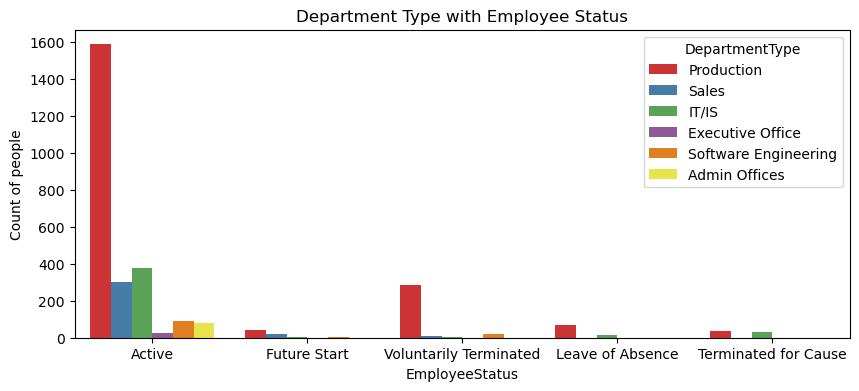

In [17]:
# Here I drew his neighbor's picture to see how many employees were still at the company compared to those who left for whatever reason
plt.figure(figsize = (10, 4))
sns.countplot(data = dataset, x = dataset.EmployeeStatus, hue = dataset.DepartmentType, palette = 'Set1')
plt.ylabel('Count of people')
plt.xlabel('EmployeeStatus')
plt.title('Department Type with Employee Status')

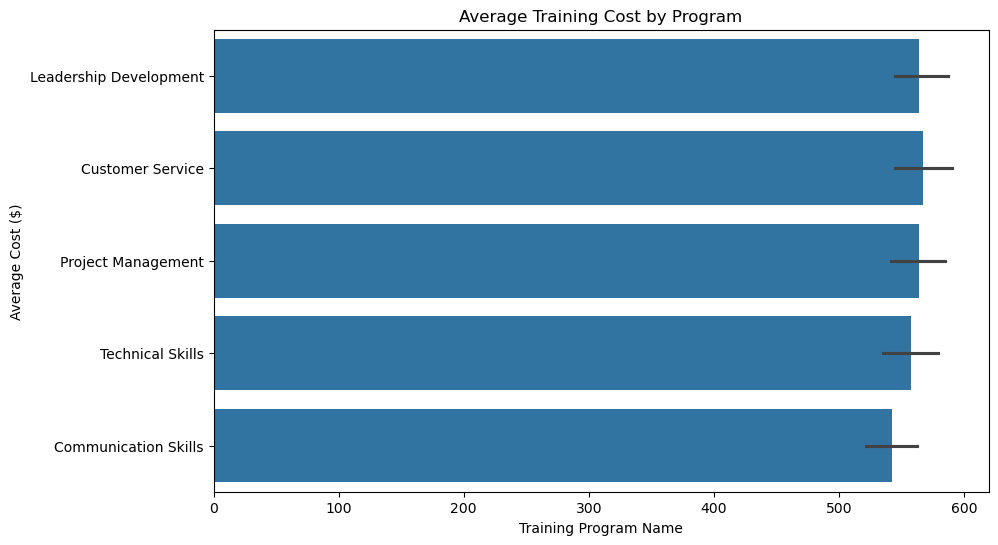

In [43]:
# Here I made a chart of bar chart because I want to see the average training on the coast
plt.figure(figsize = (10, 6))

sns.barplot(x = 'Training Cost', y = 'Training Program Name', data = dataset)

plt.title('Average Training Cost by Program')
plt.xlabel('Training Program Name')
plt.ylabel('Average Cost ($)')
plt.show()

Text(0.5, 1.0, 'Training Program Outcomes Breakdown')

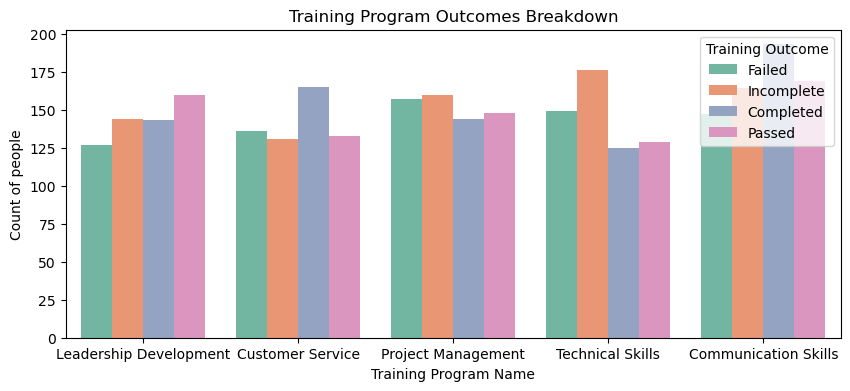

In [45]:
# I made a chart count because I want to see the type of training in the Outcomes
plt.figure(figsize = (10, 4))
sns.countplot(data = dataset, x = dataset['Training Program Name'], hue = dataset['Training Outcome'], palette = 'Set2')
plt.ylabel('Count of people')
plt.xlabel('Training Program Name')
plt.title('Training Program Outcomes Breakdown')

Text(0.5, 1.0, 'Employee Attrition and Retention by Age Group')

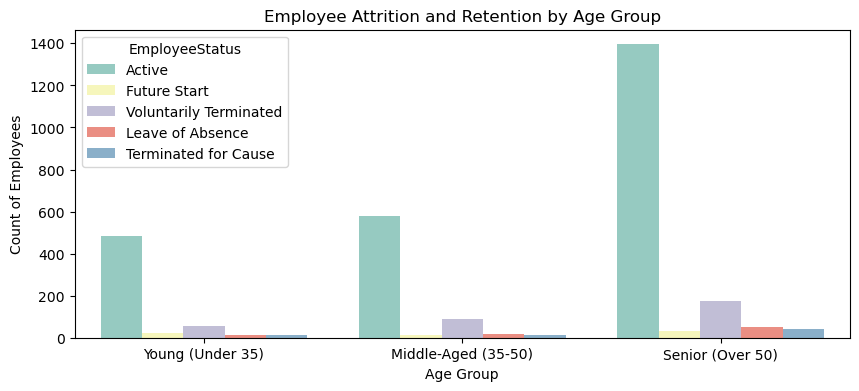

In [46]:
# I made a chart count because I want to see the relationship between an employee's age and their current position within the company
plt.figure(figsize = (10, 4))
sns.countplot(data = dataset, x = dataset['Age_Group'], hue = dataset['EmployeeStatus'], palette = 'Set3')
plt.ylabel('Count of Employees')
plt.xlabel('Age Group')
plt.title('Employee Attrition and Retention by Age Group')

Text(0.5, 1.0, 'Employee Status Breakdown by Performance Score')

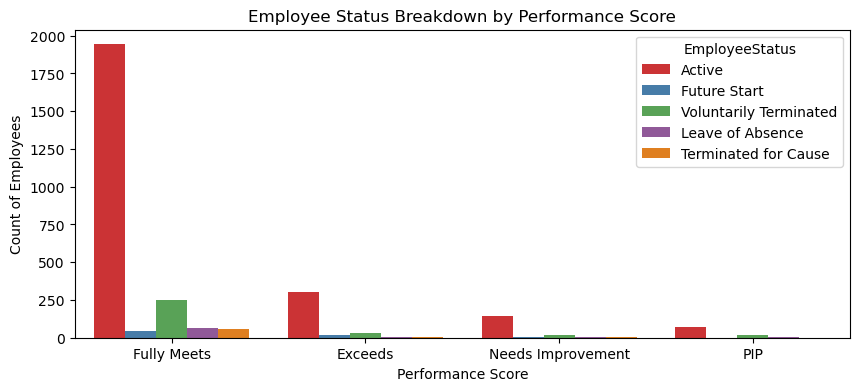

In [47]:
# I created a chart because I want to see the relationship between an employee's current position within the company and their performance evaluation
plt.figure(figsize = (10, 4))
sns.countplot(data = dataset, x = dataset['Performance Score'], hue = dataset['EmployeeStatus'], palette = 'Set1')
plt.ylabel('Count of Employees')
plt.xlabel('Performance Score')
plt.title('Employee Status Breakdown by Performance Score')

---

## Summary
__Summarizing the key insights from the analysis__

Goal: Find why good employees leave and why expensive trainings fail.  
Method: Cleaned 4 datasets and made charts using Pandas and Seaborn.  

**Results:** 
- Production department has the most resignations. 
- Company is losing young and top-performing employees.  
- High failure rates in Leadership and Technical trainings.  

## Recommendations/Conclusion
**Note**: _Use Bullet Points_

- Fix Production: Support the Production department to stop employees from leaving.
- Keep Talents: Give better rewards and promotions to young, good employees.
- Fix Training: Improve course quality so employees can pass and save budget.
- Smart Hiring: Hire the right people who fit the company culture.  